In [1]:
%run pylib/tools dark
from utilities.ipynb_docgen import show
show(f"""## Pointlike uw1616 residual map
     Load from {(filename:='files/f131maps.fits')}
     """)
from utilities.skymaps import AITfigure
from astropy.io import fits
hdus = fits.open(filename)
data = hdus[1].data

## Pointlike uw1616 residual map
Load from files/f131maps.fits

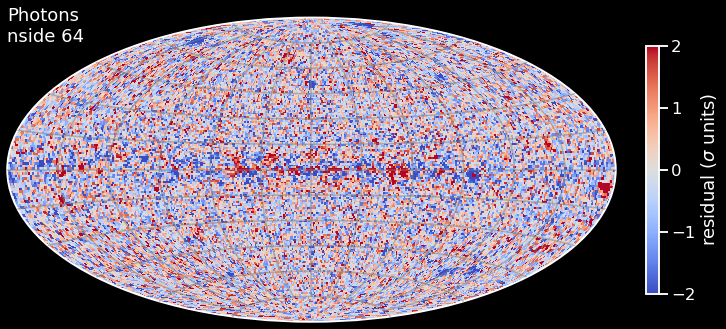

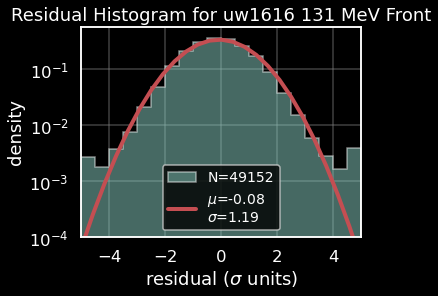

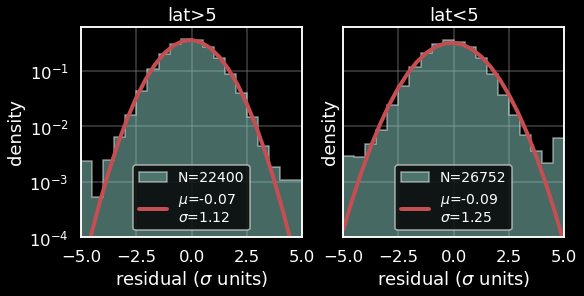

In [2]:
import astropy_healpix as healpy
nside = healpy.npix_to_nside(len(data.pulls))
att = AITfigure().title('Photons\n'+f'nside {nside}', x=0, y=0.9,ha='left')
att.imshow(hdus[1].data.pulls.clip(-2,2), vmin=-2, vmax=2, cmap='coolwarm')
att.colorbar(label=r'residual ($\sigma$ units)', shrink=0.7); 
plt.show()

def plot_resid_hist(rnorm, ax=None):
    from scipy.stats import norm
    fig, ax = plt.subplots(figsize=(5,4)) if ax is None else (ax.figure, ax)
    ylim=np.array([-5,5])

    nfit = norm.fit(rnorm[~np.isnan(rnorm)])
    ax.hist(rnorm.clip(*ylim), bins=20, range=ylim, density=True, histtype='stepfilled', alpha=0.5,
                label=f'N={len(rnorm)}' )
    ax.plot((x:=np.linspace(*ylim,num=25)), norm.pdf(x, *nfit), 'r-', lw=4,
        label =rf'$\mu$={nfit[0]:.2f}'+'\n'+ rf'$\sigma$={nfit[1]:.2f}')
    ax.legend(fontsize=14, loc='lower center',)# title='Normal fit')
    ax.set(xlabel=r'residual ($\sigma$ units)', ylabel='density', yscale='log',xlim=ylim,
           ylim=(1e-4,None))
    return ax

plot_resid_hist(data.pulls)\
    .set_title('Residual Histogram for uw1616 131 MeV Front');


lon, lat = healpy.healpix_to_lonlat(np.arange(len(data.pulls)), nside=nside)

fig, axx = plt.subplots(ncols=2, figsize=(8,4), sharey=True)
plot_resid_hist(data.pulls[np.abs(lat.deg>5)], ax=axx[0]).set_title('lat>5')
plot_resid_hist(data.pulls[np.abs(lat.deg<5)], ax=axx[1]).set_title('lat<5');